# Agent 10 — Financial Analysis

**What this notebook does:**  
Takes the stock prices downloaded in notebook 01 and calculates the key financial metrics every investor looks at: annual return, volatility (risk), maximum loss (drawdown), and the Sharpe ratio (return per unit of risk).

**How to present this to investors:**  
> *Our financial analysis agent calculates annualised return, volatility, maximum drawdown, and Sharpe ratio for each of the 50+ candidate companies, giving us a clear picture of which companies offer the best risk-adjusted returns — a necessary filter before applying sustainability criteria.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Load the most recent price file
price_files = sorted(glob.glob("../data/market/prices_*.csv"))
if not price_files:
    raise FileNotFoundError("No price file found. Run notebook 01 first.")

latest_prices = price_files[-1]
print(f"Loading prices from: {latest_prices}")
prices = pd.read_csv(latest_prices, index_col=0, parse_dates=True)
print(f"Loaded: {prices.shape[0]} days x {prices.shape[1]} stocks")

Loading prices from: ../data/market\prices_2026-05-06.csv
Loaded: 1306 days x 56 stocks


## Step 1 — Calculate daily returns

A return is simply: (today's price - yesterday's price) / yesterday's price.  
We then annualise these to get yearly figures.

In [2]:
# Remove stocks where more than 20% of price data is missing
prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.8))
print(f"Stocks with sufficient price data: {prices.shape[1]}")

# Calculate daily percentage returns
daily_returns = prices.pct_change().dropna()

TRADING_DAYS = 252  # standard assumption for annualisation

# Annualised return: average daily return × 252
annual_return = daily_returns.mean() * TRADING_DAYS

# Annualised volatility (risk): standard deviation × √252
annual_vol = daily_returns.std() * np.sqrt(TRADING_DAYS)

print("\nSample annualised returns (top 5):")
print(annual_return.sort_values(ascending=False).head())

Stocks with sufficient price data: 56

Sample annualised returns (top 5):
ASML.AS      0.565130
INGA.AS      0.414417
HEXA-B.ST    0.405480
CAP.PA       0.291043
AZN.L        0.261585
dtype: float64


## Step 2 — Sharpe Ratio

The Sharpe ratio measures how much return you get per unit of risk.  
A higher number is better. Above 1.0 is considered good.  
Formula: (Return − Risk-free rate) ÷ Volatility

In [3]:
RISK_FREE_RATE = 0.03  # 3% — approximate ECB rate (update if needed)

sharpe = (annual_return - RISK_FREE_RATE) / annual_vol
# Coerce to numeric — zero-vol or missing prices produce inf/object dtype
sharpe = pd.to_numeric(sharpe, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Risk-free rate used: {RISK_FREE_RATE*100:.1f}%")
print("\nTop 10 by Sharpe ratio:")
print(sharpe.sort_values(ascending=False).head(10))

Risk-free rate used: 3.0%

Top 10 by Sharpe ratio:
ASML.AS      1.906990
INGA.AS      1.654767
HEXA-B.ST    1.506347
ULVR.L       1.193756
BN.PA        1.119257
VOLV-B.ST    1.062045
ITX.MC       1.048952
SU.PA        1.047976
SAN.PA       1.013442
VOD.L        0.992821
dtype: float64


## Step 3 — Maximum Drawdown

The maximum drawdown is the worst peak-to-trough loss a stock experienced during the period.  
For example, -40% means the stock fell 40% from its highest point at some moment in the last 5 years.

In [4]:
def max_drawdown(price_series):
    cumulative = (1 + price_series.pct_change()).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

max_dd = prices.apply(max_drawdown)

print("Worst drawdowns (most negative = worst loss):")
print(max_dd.sort_values().head(10))

Worst drawdowns (most negative = worst loss):
ZURN.SW   -0.781207
RNO.PA    -0.622554
UCG.MI    -0.589488
ALV.DE    -0.510373
BAS.DE    -0.505904
AI.PA     -0.499426
SHEL.L    -0.496415
SAP.DE    -0.484149
BMW.DE    -0.455598
HSBA.L    -0.435784
dtype: float64


## Step 4 — Combine into one financial metrics table

In [5]:
from datetime import date

financial_metrics = pd.DataFrame({
    "annual_return_pct": (annual_return * 100).round(2),
    "annual_volatility_pct": (annual_vol * 100).round(2),
    "sharpe_ratio": sharpe.round(3),
    "max_drawdown_pct": (max_dd * 100).round(2),
    "data_vintage": str(date.today())
}).reset_index().rename(columns={"index": "ticker"})

print(f"Financial metrics calculated for {len(financial_metrics)} stocks")
financial_metrics.sort_values("sharpe_ratio", ascending=False).head(10)

Financial metrics calculated for 56 stocks


,ticker,annual_return_pct,annual_volatility_pct,sharpe_ratio,max_drawdown_pct,data_vintage
0,ASML.AS,56.51,28.06,1.907,-23.20,2026-05-06
27,INGA.AS,41.44,23.23,1.655,-21.07,2026-05-06
4,HEXA-B.ST,40.55,24.93,1.506,-26.49,2026-05-06
32,ULVR.L,23.22,16.93,1.194,-21.22,2026-05-06
34,BN.PA,20.94,16.03,1.119,-18.12,2026-05-06
49,VOLV-B.ST,23.64,19.43,1.062,-23.54,2026-05-06
39,ITX.MC,25.63,21.57,1.049,-27.06,2026-05-06
7,SU.PA,22.17,18.29,1.048,-14.22,2026-05-06
16,SAN.PA,22.41,19.15,1.013,-23.89,2026-05-06
53,VOD.L,20.37,17.49,0.993,-26.42,2026-05-06


## Step 5 — Visualise: Return vs. Risk

This chart plots every stock. Stocks in the top-left are ideal: high return, low risk.

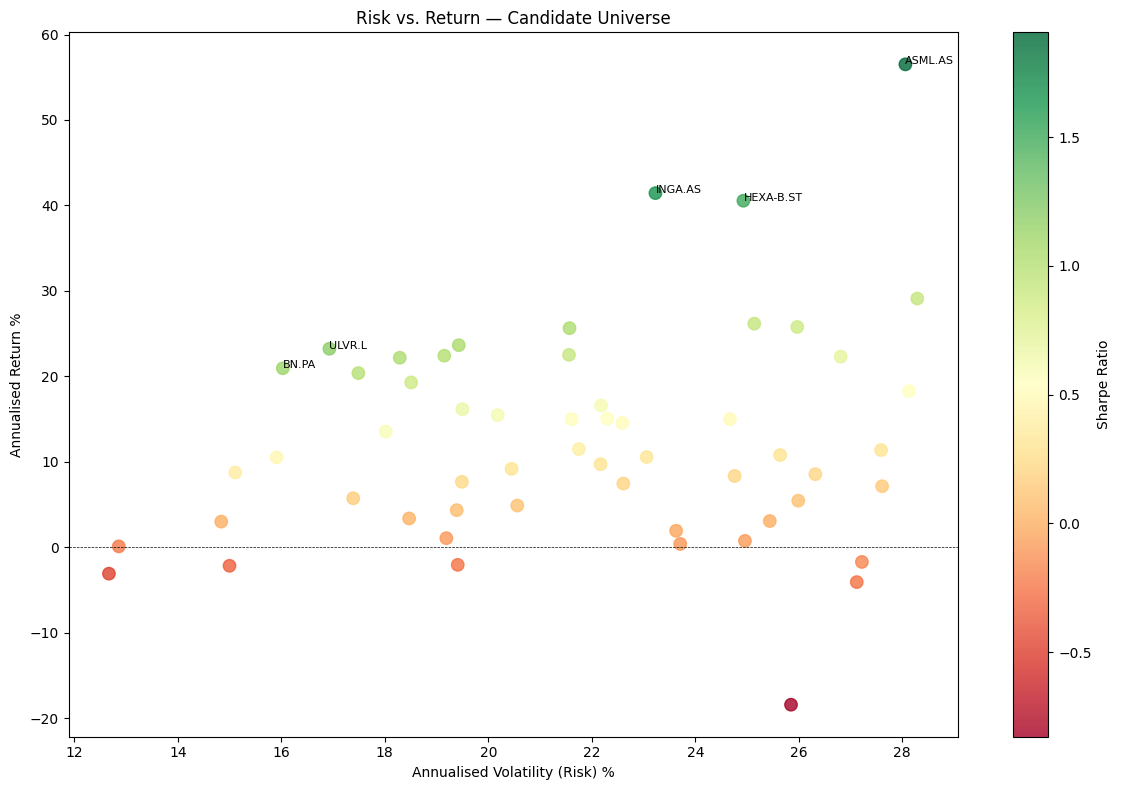

Chart saved.


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    financial_metrics["annual_volatility_pct"],
    financial_metrics["annual_return_pct"],
    c=financial_metrics["sharpe_ratio"],
    cmap="RdYlGn",
    s=80, alpha=0.8
)

plt.colorbar(scatter, label="Sharpe Ratio")
ax.set_xlabel("Annualised Volatility (Risk) %")
ax.set_ylabel("Annualised Return %")
ax.set_title("Risk vs. Return — Candidate Universe")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

# Label a few tickers
for _, row in financial_metrics.nlargest(5, "sharpe_ratio").iterrows():
    ax.annotate(row["ticker"], (row["annual_volatility_pct"], row["annual_return_pct"]),
                fontsize=8, ha="left")

plt.tight_layout()
plt.savefig("../outputs/reports/risk_return_chart.png", dpi=150)
plt.show()
print("Chart saved.")

## Step 6 — Save financial metrics

In [7]:
today = str(date.today())
out_path = f"../outputs/scores/financial_metrics_{today}.csv"
financial_metrics.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: ../outputs/scores/financial_metrics_2026-05-06.csv


## ✅ Notebook complete

You now have:
- **Annual return and volatility** for every stock
- **Sharpe ratio** (return per unit of risk)
- **Maximum drawdown** (worst historical loss)
- A **risk-return scatter chart** ready for the presentation

**Next:** Open `03_esg_scoring.ipynb` to build the ESG scores.